In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

In [27]:
import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler
import sklearn.utils as sku

# --------------------------------------------------------
# PATHS
# --------------------------------------------------------

DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/regression_nltk_sort_idx.txt"

# --------------------------------------------------------
# LABEL COLUMN STRUCTURE
# --------------------------------------------------------

LIX_COL = 0
TOPIC_COL = 1
ARTICLE_COL = 2
DATE_COL = 3

# --------------------------------------------------------
# LOAD DATA
# --------------------------------------------------------

data_articles_all = load_npz(DATA_FILE)

labels_articles_all = np.genfromtxt(
    LABEL_FILE,
    delimiter=";",
    dtype=str,
    skip_header=1
)

sort_idx = np.genfromtxt(
    SORT_FILE,
    delimiter="\n",
    dtype=int
)

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

print("Initial data shape:", data_articles_all.shape)
print("Initial number of labels:", labels_articles_all.shape[0])

# --------------------------------------------------------
# KEEP ONLY ARTICLES
# --------------------------------------------------------

article_indicator = labels_articles_all[:, ARTICLE_COL].astype(int)
article_mask = article_indicator == 1

print("\nArticles kept:", article_mask.sum())
print("Speeches removed:", (~article_mask).sum())

data_articles_all = data_articles_all[article_mask]
labels_articles_all = labels_articles_all[article_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# KEEP ONLY TOP X MOST FREQUENT ARTICLE TOPICS
# --------------------------------------------------------

top_x = 10

topics = labels_articles_all[:, TOPIC_COL]

unique_topics, topic_counts = np.unique(
    topics,
    return_counts=True
)

sorted_indices = np.argsort(topic_counts)[::-1]
valid_topics = unique_topics[sorted_indices[:top_x]]

keep_mask = np.isin(topics, valid_topics)

print("\nOriginal number of articles after removing speeches:", data_articles_all.shape[0])
print("Filtered number of articles:", keep_mask.sum())
print("Removed articles outside top topics:", data_articles_all.shape[0] - keep_mask.sum())

print("\nTop topics kept:")
for topic in valid_topics:
    count = np.sum(topics == topic)
    print(f"{topic}: {count}")

data_articles_all = data_articles_all[keep_mask]
labels_articles_all = labels_articles_all[keep_mask]

assert data_articles_all.shape[0] == labels_articles_all.shape[0]

# --------------------------------------------------------
# ADD LIX SCORE AS FIRST COLUMN
# --------------------------------------------------------

lix_scores = labels_articles_all[:, LIX_COL].astype(np.float32)

lix_column = sparse.csr_matrix(
    lix_scores.reshape(-1, 1)
)

data_articles_all = hstack(
    [lix_column, data_articles_all],
    format="csr"
)

print("Shape after adding LIX:", data_articles_all.shape)

# --------------------------------------------------------
# APPLY COLUMN SORTING / FEATURE COMBING
# --------------------------------------------------------

print("\nData columns before sorting:", data_articles_all.shape[1])
print("Smallest sort index:", sort_idx.min())
print("Largest sort index:", sort_idx.max())

sort_idx = sort_idx[
    sort_idx < data_articles_all.shape[1]
]

print("Number of valid sort indices:", len(sort_idx))

data_articles_all = data_articles_all[:, sort_idx][:, :10000]

print("Shape after combing:", data_articles_all.shape)

# --------------------------------------------------------
# SCALE FEATURES
# --------------------------------------------------------

scaler = StandardScaler(with_mean=False)

data_articles_all = scaler.fit_transform(
    data_articles_all
)

# --------------------------------------------------------
# CREATE REGRESSION LABELS: ARTICLE DATES
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

print("\nDate label summary after selecting top topics:")
print("Min year:", y_years.min())
print("Max year:", y_years.max())
print("Mean year:", y_years.mean())
print("Number of unique dates:", len(np.unique(y_years)))

print("\nTopic distribution used for regression dataset:")
filtered_topics = labels_articles_all[:, TOPIC_COL]

for topic in valid_topics:
    count = np.sum(filtered_topics == topic)
    print(f"{topic}: {count}")

# --------------------------------------------------------
# SHUFFLE DATA AND DATE LABELS
# --------------------------------------------------------

data_articles_all, y_years = sku.shuffle(
    data_articles_all,
    y_years,
    random_state=5466542
)

# --------------------------------------------------------
# OUTPUT
# --------------------------------------------------------

print("\nFinal data shape:", data_articles_all.shape)
print("Final number of date labels:", y_years.shape[0])

print("\nExample feature row:")
print(data_articles_all[0])

print("\nExample date label:")
print(y_years[0])

Initial data shape: (780044, 64478)
Initial number of labels: 780044

Articles kept: 775291
Speeches removed: 4753

Original number of articles after removing speeches: 775291
Filtered number of articles: 434564
Removed articles outside top topics: 340727

Top topics kept:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796
Shape after adding LIX: (434564, 64479)

Data columns before sorting: 64479
Smallest sort index: 0
Largest sort index: 64478
Number of valid sort indices: 64479
Shape after combing: (434564, 10000)

Date label summary after selecting top topics:
Min year: 2000.1052
Max year: 2026.4714
Mean year: 2013.8232
Number of unique dates: 9082

Topic distribution used for regression dataset:
Danmark: 128229
Internationalt: 126256
Politik: 34536
Kultur: 30699
Sport: 29083
Fodbold: 24600
Økonomi: 22715
Forbrug: 13565
Film og tv: 13085
Cykling: 11796

Final data shape: (434

In [28]:
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------
#class MyDataset(Dataset):    
    #def __init__(self, X_data, y_data):
        #self.input = X_data
        #self.truth = y_data
        
    #def __getitem__(self, index):
        #return self.input[index], self.truth[index]
        
    #def __len__ (self):
        #return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
#train_data = MyDataset(data_train, data_train_labels)
#val_data = MyDataset(data_val, data_val_labels)

import numpy as np
import pandas as pd
import torch as pt
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------------
# CREATE REGRESSION TARGET FROM ARTICLE DATE
# --------------------------------------------------------

y_years = labels_articles_all[:, DATE_COL].astype(np.float32)

valid_date_mask = ~np.isnan(y_years)

X_reg = data_articles_all[valid_date_mask]
y_years = y_years[valid_date_mask]

print("Earliest year:", y_years.min())
print("Latest year:", y_years.max())
print("Number of articles:", X_reg.shape[0])

y_scaler = StandardScaler()

y_scaled = y_scaler.fit_transform(
    y_years.reshape(-1, 1)
).astype(np.float32)

# --------------------------------------------------------
# SPLIT REGRESSION DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X_reg,
    y_scaled,
    test_size=0.1,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.20,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data_reg = MyDataset(X_train, y_train)
val_data_reg = MyDataset(X_val, y_val)

class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
test_data_reg = SparseRegressionDataset(X_test, y_test)

Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Earliest year: 2000.1052
Latest year: 2026.4714
Number of articles: 434564
Train size: 312885
Validation size: 78222
Test size: 43457


In [29]:
# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)

In [30]:
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

In [31]:
n = 1

def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-3,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128, 256]
    )

    Layer1 = trial.suggest_int("Layer1", 128*n, 512*n)
    Layer2 = trial.suggest_int("Layer2", 64*n, 256*n)
    Layer3 = trial.suggest_int("Layer3", 16*n, 64*n)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True
    )

    n_epochs = 3
    input_dim = X_train.shape[1]

    class OptRegressionModel(nn.Module):

        def __init__(self):
            super().__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, 1)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptRegressionModel().to(device)

    loss_function = nn.MSELoss()

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    train_loader = DataLoader(
        dataset=train_data_reg,
        batch_size=batch_size,
        shuffle=True
    )

    validation_loader = DataLoader(
        dataset=val_data_reg,
        batch_size=batch_size,
        shuffle=False
    )

    best_validation_loss = float("inf")

    epoch_bar = tqdm(
        range(n_epochs),
        desc=f"Trial {trial.number}",
        leave=False,
        unit="epoch"
    )

    for epoch in epoch_bar:

        model_opt.train()
        epoch_training_loss = 0.0

        train_bar = tqdm(
            train_loader,
            desc=f"Trial {trial.number} train {epoch + 1}/{n_epochs}",
            leave=False,
            position=1
        )

        for batch_idx, (input_batch, truth_batch) in enumerate(train_bar):

            input_batch = input_batch.to(device)
            truth_batch = truth_batch.to(device).view(-1, 1)

            optimizer.zero_grad()

            predictions = model_opt(input_batch)

            loss = loss_function(
                predictions,
                truth_batch
            )

            loss.backward()

            nn.utils.clip_grad_norm_(
                model_opt.parameters(),
                1.0
            )

            optimizer.step()

            epoch_training_loss += loss.item()
            running_train_loss = epoch_training_loss / (batch_idx + 1)

            train_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}",
                avg_loss=f"{running_train_loss:.4f}"
            )

        epoch_training_loss /= len(train_loader)

        model_opt.eval()
        epoch_validation_loss = 0.0

        valid_bar = tqdm(
            validation_loader,
            desc=f"Trial {trial.number} valid {epoch + 1}/{n_epochs}",
            leave=False,
            position=1
        )

        with pt.no_grad():

            for batch_idx, (input_batch, truth_batch) in enumerate(valid_bar):

                input_batch = input_batch.to(device)
                truth_batch = truth_batch.to(device).view(-1, 1)

                predictions = model_opt(input_batch)

                loss = loss_function(
                    predictions,
                    truth_batch
                )

                epoch_validation_loss += loss.item()
                running_val_loss = epoch_validation_loss / (batch_idx + 1)

                valid_bar.set_postfix(
                    batch_loss=f"{loss.item():.4f}",
                    avg_loss=f"{running_val_loss:.4f}"
                )

        epoch_validation_loss /= len(validation_loader)

        best_validation_loss = min(
            best_validation_loss,
            epoch_validation_loss
        )

        epoch_bar.set_postfix(
            train_loss=f"{epoch_training_loss:.4f}",
            val_loss=f"{epoch_validation_loss:.4f}",
            best=f"{best_validation_loss:.4f}"
        )

        trial.report(epoch_validation_loss, epoch)

        if trial.should_prune():
            raise opt.exceptions.TrialPruned()

    return best_validation_loss

In [32]:
def progress_callback(study, trial):

    optuna_bar.update(1)

    if study.best_trial is not None:
        optuna_bar.set_postfix(
            best_loss=f"{study.best_value:.4f}",
            best_trial=study.best_trial.number
        )

# HP optimization

In [33]:
class SparseRegressionDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx].toarray().squeeze()
        y = self.y[idx]

        return (
            pt.tensor(x, dtype=pt.float32),
            pt.tensor(y, dtype=pt.float32)
        )

train_data_reg = SparseRegressionDataset(X_train, y_train)
val_data_reg = SparseRegressionDataset(X_val, y_val)
#test_data_reg = SparseRegressionDataset(X_test, y_test)

In [34]:
from tqdm.auto import tqdm

n_trials = 10

pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

optuna_bar = tqdm(
    total=n_trials,
    desc="Optuna Trials",
    unit="trial"
)

device = pt.device(
    "cuda" if pt.cuda.is_available() else "cpu"
)

print(device)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[progress_callback]
)

optuna_bar.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]


[I 2026-06-10 07:43:55,799] A new study created in memory with name: no-name-85e1be26-affb-4fc7-837e-c9c4cb376aed


Optuna Trials:   0%|          | 0/10 [00:00<?, ?trial/s]

cpu


Trial 0:   0%|          | 0/3 [00:00<?, ?epoch/s]

Trial 0 train 1/3:   0%|          | 0/1223 [00:00<?, ?it/s]

...

Trial 9 valid 2/3:   0%|          | 0/1223 [00:00<?, ?it/s]

Trial 9 train 3/3:   0%|          | 0/4889 [00:00<?, ?it/s]

Trial 9 valid 3/3:   0%|          | 0/1223 [00:00<?, ?it/s]

[I 2026-06-10 09:14:33,442] Trial 9 finished with value: 1.004657731958812 and parameters: {'learning_rate': 0.0007121684674292028, 'batch_size': 64, 'Layer1': 226, 'Layer2': 127, 'Layer3': 54, 'dropout_rate': 0.14508000465368182, 'weight_decay': 0.0008199959498384498}. Best is trial 9 with value: 1.004657731958812.


Best trial:
FrozenTrial(number=9, state=<TrialState.COMPLETE: 1>, values=[1.004657731958812], datetime_start=datetime.datetime(2026, 6, 10, 9, 10, 1, 590837), datetime_complete=datetime.datetime(2026, 6, 10, 9, 14, 33, 442598), params={'learning_rate': 0.0007121684674292028, 'batch_size': 64, 'Layer1': 226, 'Layer2': 127, 'Layer3': 54, 'dropout_rate': 0.14508000465368182, 'weight_decay': 0.0008199959498384498}, user_attrs={}, system_attrs={}, intermediate_values={0: 1.0047155661555653, 1: 1.004750931399432, 2: 1.004657731958812}, distributions={'learning_rate': FloatDistribution(high=0.001, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128, 256)), 'Layer1': IntDistribution(high=512, log=False, low=128, step=1), 'Layer2': IntDistribution(high=256, log=False, low=64, step=1), 'Layer3': IntDistribution(high=64, log=False, low=16, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None), 'weight_decay': FloatDistribution(

# Split data before training

# Training

In [ ]:
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

# -------------------------
# PARAMETERS
# -------------------------

best_params = {
    "learning_rate": 1.060073845428499e-05,
    "batch_size": 2,
    "Layer1": 257,
    "Layer2": 190,
    "Layer3": 59,
    "dropout_rate": 0.3220120041094069,
    "weight_decay": 0.0004998484837983393
}

input_dim = X_train.shape[1]

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]
weight_decay = best_params["weight_decay"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = min(best_params["dropout_rate"], 0.15)

# -------------------------
# MODEL WITH 3 HIDDEN LAYERS
# -------------------------

class DateRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, Layer1),
            nn.BatchNorm1d(Layer1),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer1, Layer2),
            nn.BatchNorm1d(Layer2),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer2, Layer3),
            nn.BatchNorm1d(Layer3),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(Layer3, 1)
        )

    def forward(self, x):
        return self.network(x)

# -------------------------
# SETUP
# -------------------------

device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
model = DateRegressionModel().to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_function = nn.SmoothL1Loss(beta=0.5)

train_loader = DataLoader(
    train_data_reg,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

validation_loader = DataLoader(
    val_data_reg,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_data_reg,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False
)

n_epochs = 15
patience = 3

best_val_loss = np.inf
best_state = None
bad_epochs = 0

training_loss = []
validation_loss = []

# -------------------------
# TRAINING LOOP
# -------------------------

for epoch in tqdm(range(n_epochs), desc="Epochs", position=0):

    model.train()
    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Train {epoch + 1}/{n_epochs}",
        leave=False,
        position=1
    )

    for batch_idx, (xb, yb) in enumerate(train_bar):

        xb = xb.to(device)
        yb = yb.to(device).view(-1, 1)

        optimizer.zero_grad()

        pred = model(xb)
        loss = loss_function(pred, yb)

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()
        running_train_loss = train_loss / (batch_idx + 1)

        train_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}",
            avg_loss=f"{running_train_loss:.4f}"
        )

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    val_bar = tqdm(
        validation_loader,
        desc=f"Valid {epoch + 1}/{n_epochs}",
        leave=False,
        position=1
    )

    with pt.no_grad():
        for batch_idx, (xb, yb) in enumerate(val_bar):

            xb = xb.to(device)
            yb = yb.to(device).view(-1, 1)

            pred = model(xb)
            loss = loss_function(pred, yb)

            val_loss += loss.item()
            running_val_loss = val_loss / (batch_idx + 1)

            val_bar.set_postfix(
                batch_loss=f"{loss.item():.4f}",
                avg_loss=f"{running_val_loss:.4f}"
            )

    val_loss /= len(validation_loader)

    training_loss.append(train_loss)
    validation_loss.append(val_loss)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }
        bad_epochs = 0
        print("New best validation loss saved.")
    else:
        bad_epochs += 1
        print(f"No improvement. Bad epochs: {bad_epochs}/{patience}")

    if bad_epochs >= patience:
        print("Early stopping triggered.")
        break

# -------------------------
# LOAD BEST MODEL
# -------------------------

if best_state is not None:
    model.load_state_dict(best_state)

model.to(device)

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

Train 1/15:   0%|          | 0/156442 [00:00<?, ?it/s]

Valid 1/15:   0%|          | 0/39111 [00:00<?, ?it/s]

Epoch 001 | train loss 0.6402 | val loss 0.6295
New best validation loss saved.


Train 2/15:   0%|          | 0/156442 [00:00<?, ?it/s]

...

Epoch 002 | train loss 0.6285 | val loss 0.6244
New best validation loss saved.


Train 3/15:   0%|          | 0/156442 [00:00<?, ?it/s]

Valid 3/15:   0%|          | 0/39111 [00:00<?, ?it/s]

Epoch 003 | train loss 0.6242 | val loss 0.6231
New best validation loss saved.


Train 4/15:   0%|          | 0/156442 [00:00<?, ?it/s]

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 5.182 years
RMSE : 6.208 years
R²   : -0.014


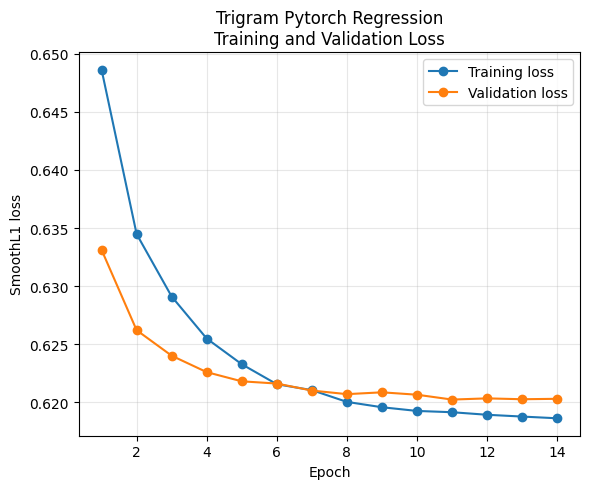

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(training_loss) + 1)

eps = 1e-12

log_train_final = np.log(training_loss[-1] + eps)
log_val_final = np.log(validation_loss[-1] + eps)
log_val_best = np.log(np.min(validation_loss) + eps)

plt.figure(figsize=(6, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss"
)



plt.xlabel("Epoch")
plt.ylabel("SmoothL1 loss")
plt.title("Trigram Pytorch Regression\nTraining and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
test_predictions_scaled = []

with pt.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        test_predictions_scaled.append(pred)

test_predictions_scaled = np.vstack(test_predictions_scaled)

true_test_years = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
predicted_test_years = y_scaler.inverse_transform(test_predictions_scaled).ravel()

mae = mean_absolute_error(true_test_years, predicted_test_years)
rmse = np.sqrt(mean_squared_error(true_test_years, predicted_test_years))
r2 = r2_score(true_test_years, predicted_test_years)

print(f"MAE  : {mae:.3f} years")
print(f"RMSE : {rmse:.3f} years")
print(f"R²   : {r2:.3f}")

MAE  : 5.182 years
RMSE : 6.208 years
R²   : -0.014


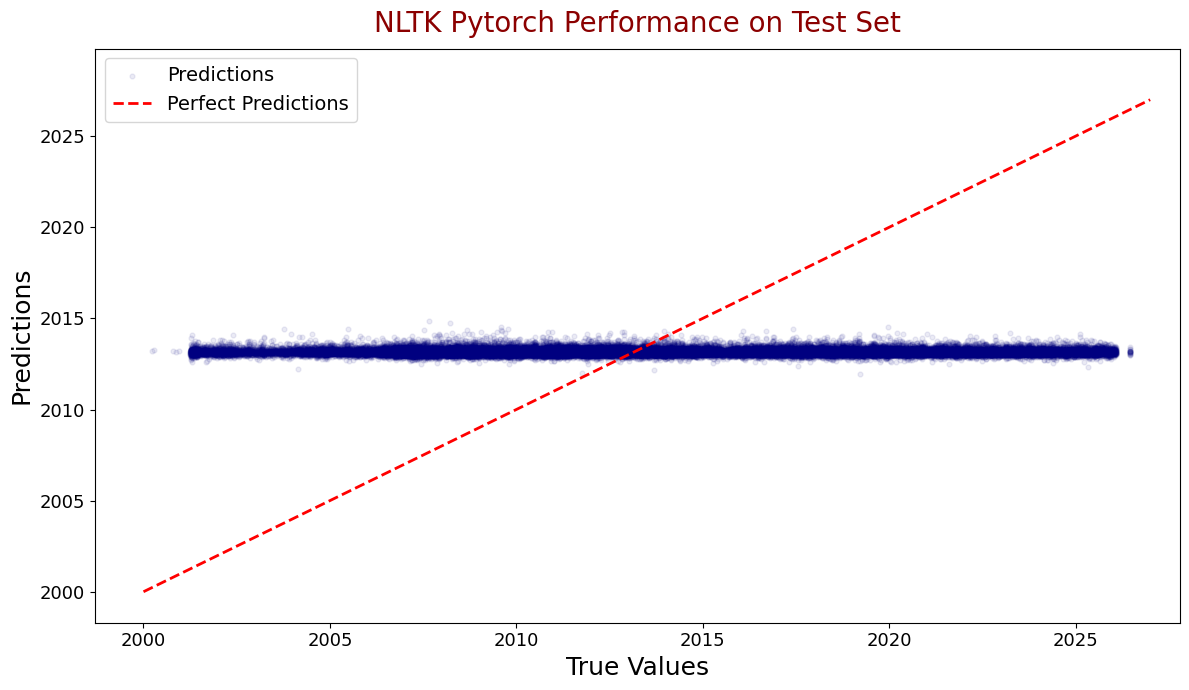

R²  = -0.013958
MSE = 38.534203


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(true_test_years, predicted_test_years)
mse = mean_squared_error(true_test_years, predicted_test_years)

year_min = 2000
year_max = 2027

plt.figure(figsize=(12, 7))

plt.scatter(
    true_test_years,
    predicted_test_years,
    s=12,
    alpha=0.08,
    color="navy",
    label="Predictions"
)

plt.plot(
    [year_min, year_max],
    [year_min, year_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Predictions"
)

plt.xlim(1998.7, 2027.8)
plt.ylim(1998.3, 2029.8)

plt.xlabel("True Values", fontsize=18)
plt.ylabel("Predictions", fontsize=18)

plt.title(
    "NLTK Pytorch Performance on Test Set",
    fontsize=20,
    color="darkred",
    pad=12
)

plt.legend(fontsize=14, loc="upper left")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.grid(False)
plt.tight_layout()

# Save figure before showing it
plt.savefig(
    "Regression_NLTK_pytorch_test_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"R²  = {r2:.6f}")
print(f"MSE = {mse:.6f}")

In [ ]:
import numpy as np
import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge
from scipy import sparse

print("========== 1. BASIC SHAPES ==========")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", np.asarray(y_train).shape)
print("y_test: ", np.asarray(y_test).shape)

ytr = np.asarray(y_train).ravel()
yte = np.asarray(y_test).ravel()

print("\n========== 2. TARGET CHECK ==========")
print("y_train min/max/mean/std:", ytr.min(), ytr.max(), ytr.mean(), ytr.std())
print("y_test  min/max/mean/std:", yte.min(), yte.max(), yte.mean(), yte.std())

if ytr.min() > 1900 and ytr.max() < 2100:
    print("Target looks like raw years.")
else:
    print("Target looks scaled/standardized. Make sure predictions are inverse-transformed before plotting as years.")

print("\n========== 3. FEATURE SPARSITY ==========")
if sparse.issparse(X_train):
    density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
    print("Sparse matrix:", True)
    print("Density:", density)
else:
    print("Sparse matrix:", False)
    print("Density:", np.count_nonzero(X_train) / X_train.size)

print("\n========== 4. MEAN BASELINE ==========")
mean_pred = np.full_like(yte, ytr.mean(), dtype=float)
print("Mean baseline MSE:", mean_squared_error(yte, mean_pred))
print("Mean baseline MAE:", mean_absolute_error(yte, mean_pred))
print("Mean baseline R2: ", r2_score(yte, mean_pred))

print("\n========== 5. RIDGE BASELINE ==========")
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, ytr)
ridge_pred = ridge.predict(X_test)

print("Ridge MSE:", mean_squared_error(yte, ridge_pred))
print("Ridge MAE:", mean_absolute_error(yte, ridge_pred))
print("Ridge R2: ", r2_score(yte, ridge_pred))
print("Ridge prediction mean/std:", ridge_pred.mean(), ridge_pred.std())

if r2_score(yte, ridge_pred) <= 0:
    print("Diagnosis: Linear baseline cannot beat the mean. Features may contain weak signal or labels may be misaligned.")

print("\n========== 6. CURRENT MODEL PREDICTION COLLAPSE TEST ==========")

try:
    model.eval()
    preds = []

    with pt.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = model(xb).detach().cpu().numpy().ravel()
            preds.append(pred)

    preds = np.concatenate(preds)

    print("Model prediction mean/std:", preds.mean(), preds.std())
    print("Target mean/std:", yte.mean(), yte.std())

    if preds.std() < 0.1 * yte.std():
        print("Diagnosis: Model predictions are collapsed near the mean.")
    elif preds.std() < 0.25 * yte.std():
        print("Diagnosis: Model has low prediction spread; partial collapse.")
    else:
        print("Prediction spread looks reasonable.")

    print("Model MSE:", mean_squared_error(yte[:len(preds)], preds))
    print("Model R2: ", r2_score(yte[:len(preds)], preds))

except Exception as e:
    print("Could not test current model predictions:", e)

print("\n========== 7. SHUFFLED-LABEL SANITY TEST ==========")

rng = np.random.default_rng(42)
ytr_shuffled = rng.permutation(ytr)

ridge_shuffle = Ridge(alpha=1.0)
ridge_shuffle.fit(X_train, ytr_shuffled)
shuffle_pred = ridge_shuffle.predict(X_test)

real_r2 = r2_score(yte, ridge_pred)
shuffle_r2 = r2_score(yte, shuffle_pred)

print("Ridge real-label R2:     ", real_r2)
print("Ridge shuffled-label R2: ", shuffle_r2)

if abs(real_r2 - shuffle_r2) < 0.02:
    print("Diagnosis: Real labels perform about like shuffled labels. Feature-target signal is very weak.")
else:
    print("Real labels beat shuffled labels, so there is some signal.")

print("\n========== 8. OVERFIT TINY SUBSET TEST ==========")

# This checks whether the neural network can memorize 512 examples.
# If it cannot, there is likely a training/model/data-format bug.

n_small = 512

if sparse.issparse(X_train):
    X_small = X_train[:n_small].toarray().astype("float32")
else:
    X_small = np.asarray(X_train[:n_small]).astype("float32")

y_small = ytr[:n_small].astype("float32").reshape(-1, 1)

small_dataset = TensorDataset(
    pt.tensor(X_small, dtype=pt.float32),
    pt.tensor(y_small, dtype=pt.float32)
)

small_loader = DataLoader(
    small_dataset,
    batch_size=64,
    shuffle=True
)

class TinyOverfitModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

small_device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
small_model = TinyOverfitModel(X_small.shape[1]).to(small_device)

small_optimizer = optim.Adam(
    small_model.parameters(),
    lr=1e-3,
    weight_decay=0.0
)

small_loss_fn = nn.MSELoss()

for epoch in range(50):
    small_model.train()
    loss_sum = 0.0

    for xb, yb in small_loader:
        xb = xb.to(small_device)
        yb = yb.to(small_device)

        small_optimizer.zero_grad()
        pred = small_model(xb)
        loss = small_loss_fn(pred, yb)
        loss.backward()
        small_optimizer.step()

        loss_sum += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Tiny overfit epoch {epoch+1:03d}, loss={loss_sum / len(small_loader):.6f}")

small_model.eval()
with pt.no_grad():
    small_preds = small_model(
        pt.tensor(X_small, dtype=pt.float32).to(small_device)
    ).cpu().numpy().ravel()

tiny_r2 = r2_score(y_small.ravel(), small_preds)
tiny_mse = mean_squared_error(y_small.ravel(), small_preds)

print("Tiny subset train MSE:", tiny_mse)
print("Tiny subset train R2: ", tiny_r2)

if tiny_r2 < 0.8:
    print("Diagnosis: Network cannot memorize a tiny subset. There may be a model/training/data bug.")
else:
    print("Network can memorize a tiny subset. Main problem is likely weak generalizable signal, not code mechanics.")

print("\n========== 9. FINAL DIAGNOSIS GUIDE ==========")
print("""
If Ridge R2 <= 0 and shuffled-label R2 is similar:
    Features probably do not predict year well.

If model prediction std is tiny:
    Neural net collapsed to predicting the mean year.

If tiny subset R2 is low:
    There is likely a training-loop, target-shape, dtype, or model bug.

If tiny subset R2 is high but test R2 is poor:
    The model can learn, but the features do not generalize to year prediction.
""")

========== 1. BASIC SHAPES ==========
X_train: (312885, 10000)
X_test:  (43457, 10000)
y_train: (312885, 1)
y_test:  (43457, 1)

========== 2. TARGET CHECK ==========
y_train min/max/mean/std: -2.2214377 2.0481942 0.00019843243 0.99966425
y_test  min/max/mean/std: -2.203054 2.0481942 0.00743992 0.9982882
Target looks scaled/standardized. Make sure predictions are inverse-transformed before plotting as years.

========== 3. FEATURE SPARSITY ==========
Sparse matrix: True
Density: 0.0040029221598990045

========== 4. MEAN BASELINE ==========
Mean baseline MSE: 0.9966317540213205
Mean baseline MAE: 0.8428644990519393
Mean baseline R2:  -5.2619144623733405e-05

========== 5. RIDGE BASELINE ==========
Ridge MSE: 1.029773023429318
Ridge MAE: 0.8534605975603882
Ridge R2:  -0.03330764351999238
Ridge prediction mean/std: 0.0007512693795579354 0.18483844817117095
Diagnosis: Linear baseline cannot beat the mean. Features may contain weak signal or labels may be misaligned.

========== 6. CURRENT 

In [ ]:
print(X_train.shape[1] == X_test.shape[1])

True
